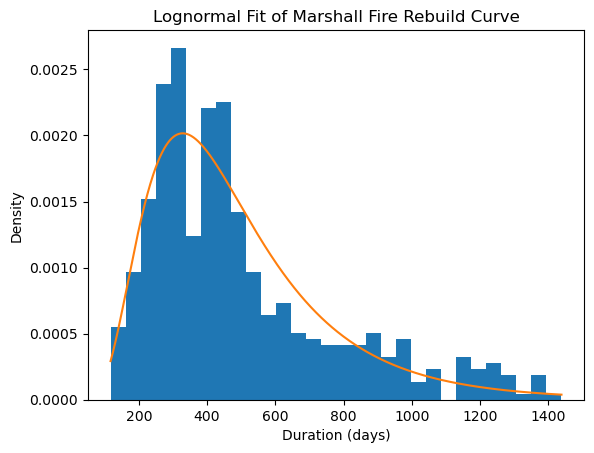

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

df = pd.read_csv("disaster_to_application_louisville.csv")
data = df["duration_days"]

shape, loc, scale = lognorm.fit(data, floc=0)

x = np.linspace(min(data), max(data), 1000)

plt.hist(data, bins=30, density=True)
plt.plot(x, lognorm.pdf(x, shape, loc, scale))

plt.xlabel("Duration (days)")
plt.ylabel("Density")
plt.title("Lognormal Fit of Marshall Fire Rebuild Curve")
plt.show()

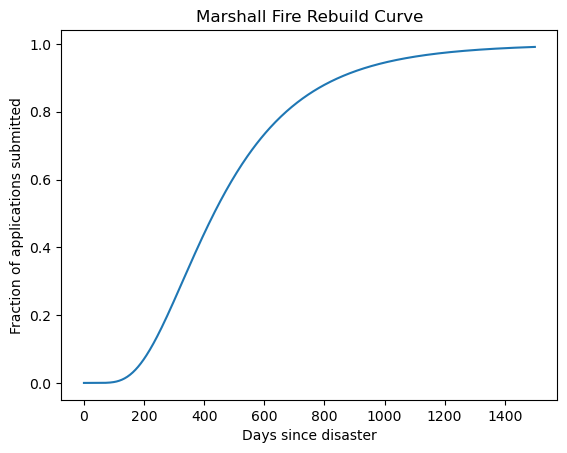

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

x = np.linspace(0, 1500, 500)

cdf = lognorm.cdf(x, shape, loc, scale)

plt.plot(x, cdf)
plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Marshall Fire Rebuild Curve")
plt.show()

In [3]:
N = 6410   # example total damaged homes

predicted_apps = N * cdf

pdf = lognorm.pdf(x, shape, loc, scale)
daily_submissions = N * pdf

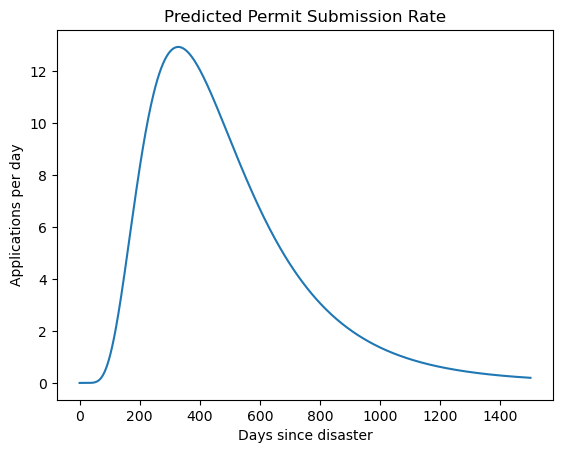

In [4]:
plt.plot(x, daily_submissions)
plt.xlabel("Days since disaster")
plt.ylabel("Applications per day")
plt.title("Predicted Permit Submission Rate")
plt.show()

In [5]:
print(shape)
print(loc)
print(scale)

0.5250260688883092
0
432.50326827660706


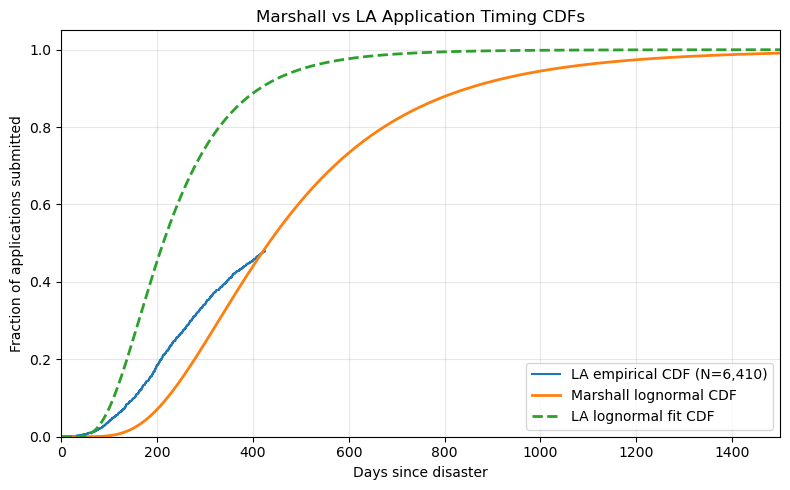

In [6]:
# LA data + lognormal fit + comparison with Marshall CDF

# Load LA data
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values

# Fit a lognormal to LA data (fix location at 0 like Marshall)
shape_la, loc_la, scale_la = lognorm.fit(data_la, floc=0)

# Use the same x-grid as for Marshall
x_grid = x

# Marshall Fire CDF (already computed as `cdf`)
cdf_marshall = cdf

# LA fitted lognormal CDF
cdf_la_fit = lognorm.cdf(x_grid, shape_la, loc_la, scale_la)

# Empirical CDF for LA, scaled by total expected applications N = 6410
N_la = 6410
data_la_sorted = np.sort(data_la)
empirical_cdf_la = np.arange(1, len(data_la_sorted) + 1) / N_la

plt.figure(figsize=(8, 5))

# Empirical CDF for LA
plt.step(data_la_sorted, empirical_cdf_la, where="post", label="LA empirical CDF (N=6,410)")

# Marshall Fire lognormal CDF
plt.plot(x_grid, cdf_marshall, label="Marshall lognormal CDF", linewidth=2)

# LA lognormal fit CDF
plt.plot(x_grid, cdf_la_fit, label="LA lognormal fit CDF", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Marshall vs LA Application Timing CDFs")
plt.xlim(0, 1500)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

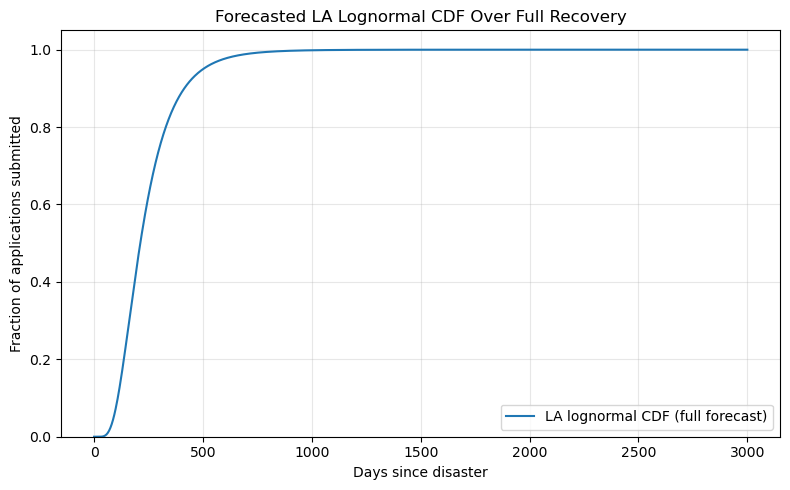

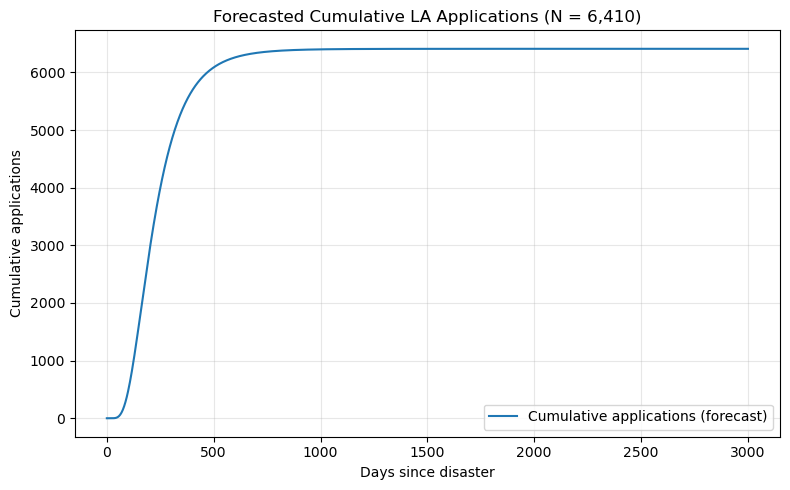

In [9]:
# Forecast LA lognormal CDF and applications over full recovery

# Use the LA lognormal fit you already estimated:
# shape_la, loc_la, scale_la

N_la = 6410  # total expected applications

# Choose a horizon long enough to see the curve saturate
x_forecast = np.linspace(0, 3000, 1000)  # days since disaster

# Full (unscaled) LA lognormal CDF and PDF
cdf_la_full = lognorm.cdf(x_forecast, shape_la, loc_la, scale_la)
pdf_la_full = lognorm.pdf(x_forecast, shape_la, loc_la, scale_la)

# Forecast cumulative and daily applications
cum_apps_la = N_la * cdf_la_full          # cumulative forecast
daily_apps_la = N_la * pdf_la_full        # daily forecast

plt.figure(figsize=(8, 5))
plt.plot(x_forecast, cdf_la_full, label="LA lognormal CDF (full forecast)")
plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Forecasted LA Lognormal CDF Over Full Recovery")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_forecast, cum_apps_la, label="Cumulative applications (forecast)")
plt.xlabel("Days since disaster")
plt.ylabel("Cumulative applications")
plt.title("Forecasted Cumulative LA Applications (N = 6,410)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

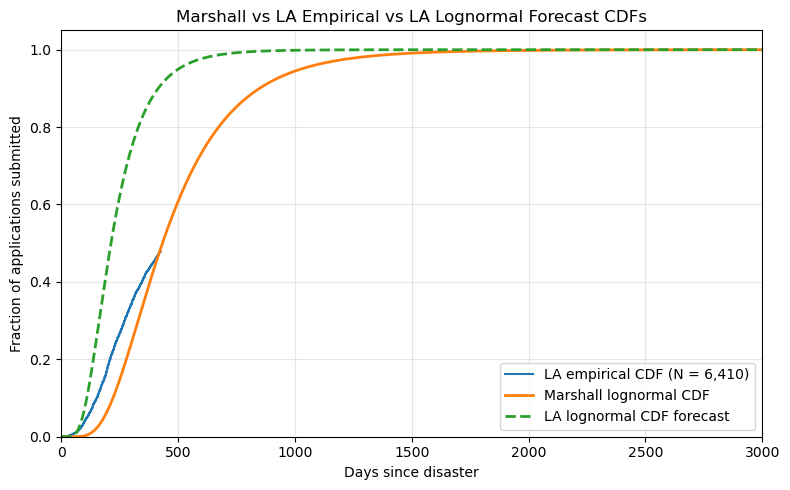

In [10]:
# Marshall vs LA empirical vs LA lognormal forecast

N_la = 6410

# Horizon for plotting (longer so we see the full forecast)
x_forecast = np.linspace(0, 3000, 1000)

# Marshall lognormal CDF on same horizon (using Marshall fit: shape, loc, scale)
cdf_marshall_forecast = lognorm.cdf(x_forecast, shape, loc, scale)

# LA full lognormal CDF forecast (unscaled, goes to 1)
cdf_la_forecast = lognorm.cdf(x_forecast, shape_la, loc_la, scale_la)

# LA empirical CDF (scaled by N = 6,410)
df_la = pd.read_csv("disaster_to_application_la.csv")
data_la = df_la["duration_days"].values
data_la_sorted = np.sort(data_la)
empirical_cdf_la = np.arange(1, len(data_la_sorted) + 1) / N_la

plt.figure(figsize=(8, 5))

# LA empirical CDF
plt.step(data_la_sorted, empirical_cdf_la, where="post",
         label="LA empirical CDF (N = 6,410)")

# Marshall lognormal CDF
plt.plot(x_forecast, cdf_marshall_forecast, label="Marshall lognormal CDF", linewidth=2)

# LA lognormal forecast CDF
plt.plot(x_forecast, cdf_la_forecast, label="LA lognormal CDF forecast", linestyle="--", linewidth=2)

plt.xlabel("Days since disaster")
plt.ylabel("Fraction of applications submitted")
plt.title("Marshall vs LA Empirical vs LA Lognormal Forecast CDFs")
plt.xlim(0, 3000)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
